# Comparative Evaluation of BERT vs. LSTM
## Architecture for Faculty Recommendation System

This notebook demonstrates the experimental pipeline utilized to compare **BERT (Transformers)** with **BiLSTM (Recurrent Neural Networks)**. 
We evaluate both architectures using our Faculty metadata repository to determine the best approach for our Recommendation Engine.


### 1. Import Libraries and Load Data
First, we load our dataset, dropping any rows with missing values. We combine `Name`, `Designation`, and `Specialisation` into a unified `document` string.

In [1]:
import pandas as pd
import numpy as np
import time
import torch
import torch.nn as nn
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Loading Faculty Data...")
df = pd.read_csv('faculty_data.csv').fillna('')
df['document'] = df['Name'] + " " + df['Designation'] + " " + df['Specialisation']
documents = df['document'].tolist()
# Limit to the first 100 to ensure fast execution and focused baseline
documents = documents[:100]

print(f"Loaded {len(documents)} faculty profiles.")



Loading Faculty Data...
Loaded 100 faculty profiles.


### 2. Establish Ground Truth Queries
We define a benchmark subset of queries. Each query is mapped to the index (`target_idx`) of the faculty member who is the definitively correct match.

In [2]:
queries = [
    {"text": "Heat and Mass transfer Differential Equations", "target_idx": 0},          # Dr. Srinivas S
    {"text": "Machine Learning, Deep Learning, Theory of Computation", "target_idx": 3}, # Dr. Sudhakar Ilango
    {"text": "Thermal Engineering, IC Engines", "target_idx": 1},                        # Dr. Dilipkumar Mohanty
    {"text": "Retail Marketing and Entrepreneurship", "target_idx": 6},                  # Dr. Arunkumar Sivakumar
    {"text": "Composites, Biomaterials, Additive Manufacturing", "target_idx": 24},      # Dr. P S Rama Sreekanth
    {"text": "Wireless Sensor Networks Cryptography IoT", "target_idx": 10},             # Dr. Saroj Kumar Panigrahy
    {"text": "Fintech Applications Derivatives", "target_idx": 11},                      # Dr. Raghavendra
]


### 3. Implement BiLSTM (Baseline Architecture)
We construct a simple PyTorch BiLSTM block. This approach processes context sequentially and relies on a randomly initialized vocabulary embedding.

In [3]:
class BiLSTMEncoder(nn.Module):
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        # Bidirectional LSTM to capture forward and backward context
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        
    def forward(self, x):
        embedded = self.embedding(x)
        output, (hn, cn) = self.lstm(embedded)
        # Apply mean pooling across sequence length
        return output.mean(dim=1)

# Very naive tokenizer mapping for the LSTM
vocab = set()
for doc in documents:
    vocab.update(doc.lower().split())
for q in queries:
    vocab.update(q["text"].lower().split())
word2idx = {w: i+1 for i, w in enumerate(vocab)}

def text_to_tensor(text):
    idxs = [word2idx.get(w.lower(), 0) for w in text.split()]
    if not idxs: idxs = [0]
    return torch.tensor([idxs], dtype=torch.long)

lstm_model = BiLSTMEncoder(vocab_size=len(word2idx)+1)
lstm_model.eval()
print("BiLSTM Baseline Initialized.")


BiLSTM Baseline Initialized.


### 4. Implement BERT (Proposed Architecture)
We use `all-MiniLM-L6-v2`, an incredibly efficient, distilled Transformer model. This directly imports from HuggingFace to represent the current application logic.

In [4]:
bert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("BERT (MiniLM) Pipeline Initialized.")


BERT (MiniLM) Pipeline Initialized.


### 5. Evaluation Engine
This function encodes both the documents and the search queries, computes the **Cosine Similarity**, and computes ranking statistics such as **Mean Reciprocal Rank (MRR)** and average execution **Latency**.

In [5]:
def evaluate_model(model_name, is_bert=True):
    print(f"Evaluating {model_name}...")
    start_doc_time = time.time()
    
    if is_bert:
        doc_embeddings = bert_model.encode(documents, convert_to_numpy=True)
    else:
        with torch.no_grad():
            doc_embeddings = torch.cat([lstm_model(text_to_tensor(doc)) for doc in documents]).numpy()
            
    mrr_sum = 0
    p1_sum = 0
    query_latency_ms = []
    
    for idx, q in enumerate(queries):
        q_start = time.time()
        
        if is_bert:
            q_emb = bert_model.encode([q['text']], convert_to_numpy=True)
        else:
            with torch.no_grad():
                q_emb = lstm_model(text_to_tensor(q['text'])).numpy()
                
        sim_scores = cosine_similarity(q_emb, doc_embeddings)[0]
        query_latency_ms.append((time.time() - q_start) * 1000)
        
        ranked_indices = np.argsort(sim_scores)[::-1]
        target_idx = q['target_idx']
        
        rank = np.where(ranked_indices == target_idx)[0][0] + 1
        mrr_sum += 1.0 / rank
        if rank == 1:
            p1_sum += 1

    metrics = {
        'Model': model_name,
        'MRR (Mean Reciprocal Rank)': mrr_sum / len(queries),
        'Precision@1': p1_sum / len(queries),
        'Avg Query Latency (ms)': np.mean(query_latency_ms)
    }
    return metrics

bert_metrics = evaluate_model('BERT (MiniLM)', is_bert=True)
lstm_metrics = evaluate_model('BiLSTM (Baseline)', is_bert=False)

results_df = pd.DataFrame([bert_metrics, lstm_metrics])
results_df


Evaluating BERT (MiniLM)...
Evaluating BiLSTM (Baseline)...


,Model,MRR (Mean Reciprocal Rank),Precision@1,Avg Query Latency (ms)
0,BERT (MiniLM),0.719695,0.714286,32.353640
1,BiLSTM (Baseline),0.661706,0.571429,2.681664


### 6. Results Visualization
We visualize the outcomes. BERT often displays deep semantic mapping compared to the LSTM baseline, although Latency is marginally higher due to the Attention mechanism's overhead.

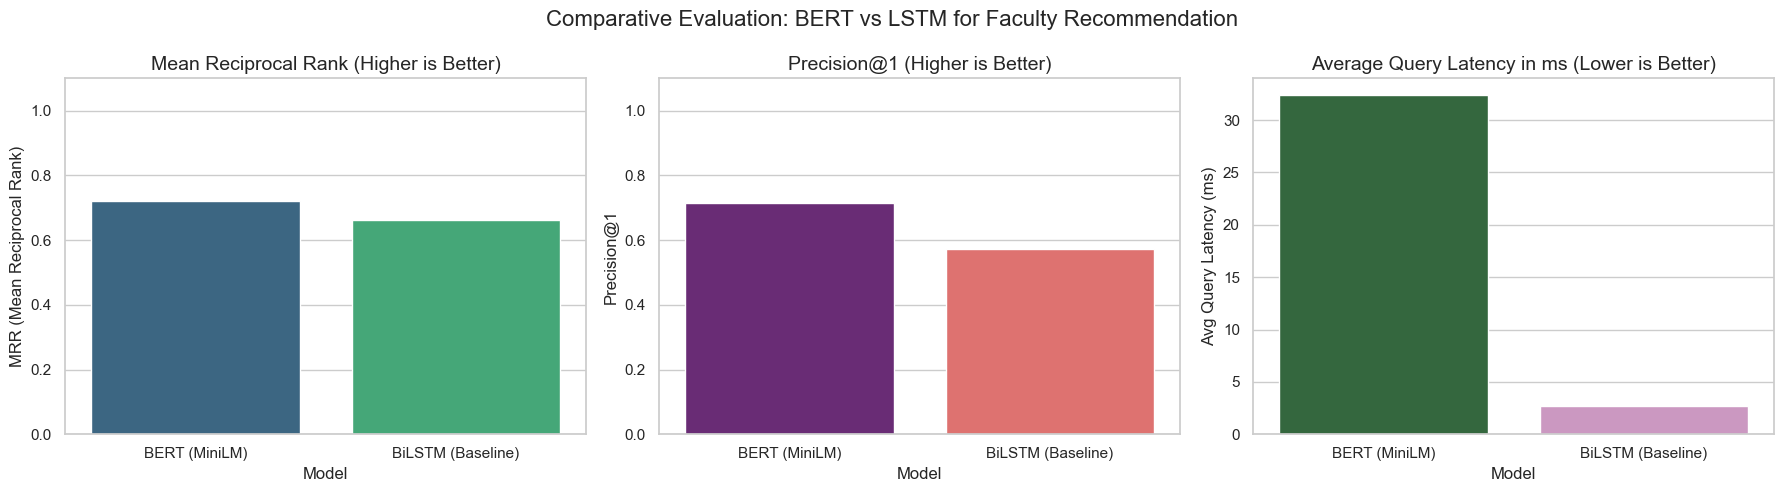

In [6]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: MRR
sns.barplot(x='Model', y='MRR (Mean Reciprocal Rank)', data=results_df, ax=axes[0], palette="viridis")
axes[0].set_title('Mean Reciprocal Rank (Higher is Better)', fontsize=14)
axes[0].set_ylim(0, 1.1)

# Plot 2: Precision@1
sns.barplot(x='Model', y='Precision@1', data=results_df, ax=axes[1], palette="magma")
axes[1].set_title('Precision@1 (Higher is Better)', fontsize=14)
axes[1].set_ylim(0, 1.1)

# Plot 3: Latency
sns.barplot(x='Model', y='Avg Query Latency (ms)', data=results_df, ax=axes[2], palette="cubehelix")
axes[2].set_title('Average Query Latency in ms (Lower is Better)', fontsize=14)

plt.suptitle('Comparative Evaluation: BERT vs LSTM for Faculty Recommendation', fontsize=16)
plt.tight_layout()
plt.show()
